# Модели семейства ARIMA для предсказания стоимости акций

ARIMA модели - семейство моделей анализа временных рядов. Модель SARIMAX даже позволяет добавить внешние признаки, например, цены других акций, или стоимость индекса мосбиржи.

SARIMAX состоит из нескольких частей:
- **S** - сезонность
- **AR** - авторегрессия (зависимость текущего значения от предыдущих значений ряда)
- **I** - интегрирование (дифференцируем ряд, чтобы сделать его стационарным)
- **MA** - скользящее среднее (зависимость текущего значения от прошлых ошибок модели)
- **X** - eXogenous variables (внешние факторы)

# Функции

In [233]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def train_test_split_by_date(df, date_column='begin', target_column='close', test_size=0.2):
    """
    Разбивает данные на train/test по дате и возвращает X, y
    
    Args:
        df: DataFrame с колонкой 'begin'
        target_column: название целевой переменной
        test_size: доля тестовых данных (0.2 = 20%)
    """
    df = df.sort_values(date_column).reset_index(drop=True)
    
    # Вычисляем индекс разбиения
    split_idx = int(len(df) * (1 - test_size))
    
    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()
    
    print(f"Train: {train_df[date_column].min()} - {train_df[date_column].max()} ({len(train_df)} samples)")
    print(f"Test:  {test_df[date_column].min()} - {test_df[date_column].max()} ({len(test_df)} samples)")
    
    # Удаляем колонку 'begin' и разделяем на X, y
    X_train = train_df.drop(columns=[date_column, target_column])
    y_train = train_df[target_column]
    
    X_test = test_df.drop(columns=[date_column, target_column])
    y_test = test_df[target_column]
    
    print(f"Признаков: {X_train.shape[1]}")
    
    return X_train, X_test, y_train, y_test

def visualize_predictions_comparison(
    results_df, title, y_label, date_column='begin', target_column='close', predict_column='predict',):
    """
    Визуализирует сравнение предсказаний и реальных изменений цены
    
    Args:
        results_df: DataFrame
        title: str, заголовок графика
        y_label: str, название оси Y
        date_column: str, название столбца с датой
        target_column: str, название столбца с target значениями
        predict_column: str, название столбца с предсказанными значениями
    """
    # Конвертируем дату если нужно
    if results_df[date_column].dtype == 'object':
        results_df = results_df.copy()
        results_df[date_column] = pd.to_datetime(results_df[date_column])
    
    # Сортируем по дате
    results_df = results_df.sort_values(date_column)
    
    fig = go.Figure()

    # Target
    fig.add_trace(
        go.Scatter(
            x=results_df[date_column],
            y=results_df[target_column],
            mode="lines+markers",
            name="target",
            line=dict(width=3, color="#2E8B57"),
            marker=dict(symbol="circle", size=6),
            opacity=0.8
        )
    )

    # Prediction
    fig.add_trace(
        go.Scatter(
            x=results_df[date_column],
            y=results_df[predict_column],
            mode="lines+markers",
            name="prediction",
            line=dict(width=3, color="#DC143C"),
            marker=dict(symbol="square", size=6),
            opacity=0.8
        )
    )

    # Нулевая линия
    fig.add_hline(
        y=0,
        line_width=1,
        line_dash="solid",
        line_color="black",
        opacity=0.5
    )

    fig.update_layout(
        title=dict(
            text=title,
            x=0.5,
            xanchor="center",
            font=dict(size=18)
        ),
        xaxis_title="Дата",
        yaxis_title=y_label,
        template="plotly_white",
        width=1200,
        height=600,
        hovermode="x unified"
    )

    fig.update_xaxes(
        tickangle=45,
        showgrid=True
    )

    fig.update_yaxes(
        showgrid=True
    )

    fig.show()

def evaluate_regression(y_test, y_pred, model_name=""):
    """Оценивает результаты регрессии"""
    print(f"\n{'='*50}")
    print(f"📊 МОДЕЛЬ: {model_name}")
    print(f"{'='*50}")
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # Accuracy направления (важно для торговли)
    direction_accuracy = np.mean((y_test > 0) == (y_pred > 0))
    
    print(f"MAE: {mae:.4f}%")
    print(f"RMSE: {rmse:.4f}%")
    print(f"R²: {r2:.4f}")
    print(f"Accuracy направления: {direction_accuracy:.4f}")

def add_target_after_time_delta(df, time_delta, date_column='begin', price_column='close', target_date_column='target_date', target_price_column='target'):
    """Добавляет столбец с целевой переменной - изменением цены через time_delta дней"""
    df = df.copy()
    df[target_price_column] = df[price_column].shift(-time_delta)
    df[target_date_column] = df[date_column].shift(-time_delta)
    return df

In [234]:
def log_return(series, periods=1):
    return np.log(series / series.shift(periods))


def inverse_log_return(log_ret, prev_price):
    return prev_price * np.exp(log_ret)

In [235]:
def _test_log_return():
    prices = pd.Series([100.0, 110.0, 121.0])
    log_ret = log_return(prices)
    log_ret_reversed = inverse_log_return(log_ret, prices.shift(1))
    assert np.allclose(prices[1:], log_ret_reversed[1:], rtol=1e-6)

_test_log_return()

## 1. Анализ стоимости акций

### 1.1. Загружаем данные

In [236]:
# Хак, чтобы добавить корень проекта в path для импорта модулей
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[1]))
sys.path

['/usr/lib/python312.zip',
 '/usr/lib/python3.12',
 '/usr/lib/python3.12/lib-dynload',
 '',
 '/home/codevryn/stocks-advisor/.venv/lib/python3.12/site-packages',
 '/home/codevryn/stocks-advisor',
 '/home/codevryn/stocks-advisor',
 '/home/codevryn/stocks-advisor']

In [237]:
from datetime import datetime

from app.core.clients.moex import Boards, Engines, Interval, Markets, MOEXClient

moex_client = MOEXClient()
stocks_data = await moex_client.get_data(
    tickers=['GAZP', 'LKOH', 'ROSN', 'SBER'],
    engine=Engines.STOCK,
    market=Markets.SHARES,
    board=Boards.TQBR,
    start_date=datetime(2022, 5, 1),
    end_date=datetime.now(),
    interval=Interval.HOUR_1,
)

In [238]:
stocks_data.keys()

dict_keys(['GAZP', 'LKOH', 'ROSN', 'SBER'])

In [239]:
stocks_data['GAZP'].describe()

,open,close,high,low,value,volume,begin,end
count,15855.000000,15855.000000,15855.000000,15855.000000,1.585500e+04,1.585500e+04,15855,15855
mean,152.022892,152.003874,152.444388,151.552467,4.854730e+08,3.222955e+06,2024-06-15 18:37:12.658467328,2024-06-15 19:37:01.418668800
min,105.620000,105.650000,105.850000,105.220000,3.017040e+04,2.600000e+02,2022-05-04 09:00:00,2022-05-04 09:59:59
25%,127.040000,127.040000,127.390000,126.700000,1.031883e+08,6.989950e+05,2023-07-04 12:30:00,2023-07-04 13:29:59
50%,153.120000,153.100000,153.610000,152.600000,2.484884e+08,1.650930e+06,2024-07-16 17:00:00,2024-07-16 17:59:59
75%,167.600000,167.605000,167.990000,167.220000,5.574762e+08,3.784575e+06,2025-06-11 19:30:00,2025-06-11 20:29:59
max,320.800000,320.800000,322.990000,319.590000,2.385369e+10,1.410863e+08,2026-03-12 14:00:00,2026-03-12 14:53:02
std,32.385760,32.366612,32.535161,32.202970,8.563057e+08,5.249108e+06,NaN,NaN


In [240]:
stocks_data['GAZP'].head()

,open,close,high,low,value,volume,begin,end,ticker
0,241.00,241.00,241.00,241.00,1.779544e+07,73840,2022-05-04 09:00:00,2022-05-04 09:59:59,GAZP
1,241.01,238.90,244.39,238.00,1.687852e+09,7012280,2022-05-04 10:00:00,2022-05-04 10:59:59,GAZP
2,238.95,233.80,240.20,233.50,1.187417e+09,5025080,2022-05-04 11:00:00,2022-05-04 11:59:59,GAZP
3,233.71,235.63,236.30,233.17,5.070772e+08,2159900,2022-05-04 12:00:00,2022-05-04 12:59:59,GAZP
4,235.63,234.61,235.84,233.90,3.604205e+08,1535620,2022-05-04 13:00:00,2022-05-04 13:59:59,GAZP


### 1.2. Обработка данных

In [241]:
stocks_data_processed = {}

for k, v_df in stocks_data.items():
    stocks_data_processed[k] = v_df[['begin', 'close']]

stocks_data_processed['GAZP'].head()

,begin,close
0,2022-05-04 09:00:00,241.00
1,2022-05-04 10:00:00,238.90
2,2022-05-04 11:00:00,233.80
3,2022-05-04 12:00:00,235.63
4,2022-05-04 13:00:00,234.61


In [242]:
# Возьмем только основную сессию

stocks_data_main_session = {}

for ticker, df in stocks_data_processed.items():
    df = df.copy()
    df['hour'] = df['begin'].dt.hour
    # Основная сессия на Мосбирже: с 9:50 по 18:50.
    stocks_data_main_session[ticker] = df[df['hour'].between(10, 18)].drop(columns='hour')
    # Уберем выходные дни
    stocks_data_main_session[ticker] = stocks_data_main_session[ticker][stocks_data_main_session[ticker]['begin'].dt.dayofweek < 5]

stocks_data_main_session['GAZP'].shape

(8786, 2)

In [243]:
# Посмотрим на данные

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=stocks_data_processed['GAZP']["begin"],
        y=stocks_data_processed['GAZP']["close"],
        mode="lines",
        name="Close price"
    )
)

fig.update_layout(
    title="GAZP",
    xaxis_title="Date",
    yaxis_title="Price",
    template="plotly_white"
)

fig.show()

### 1.3. Анализ цены акций

Пока попробуем проанализировать цены акций "в лоб" для бэйзлайна

In [244]:
# # Добавим разные таргеты:
# # - цена через час
# # - цена через день
# # - цена через неделю

# stocks_data_1h = {}
# stocks_data_1d = {}
# stocks_data_1w = {}

# for ticker, df in stocks_data_processed.items():
#     stocks_data_1h[ticker] = add_target_after_time_delta(df, time_delta=1, date_column='begin', price_column='close', target_price_column='target')
#     stocks_data_1d[ticker] = add_target_after_time_delta(df, time_delta=24, date_column='begin', price_column='close', target_price_column='target')
#     stocks_data_1w[ticker] = add_target_after_time_delta(df, time_delta=24*7, date_column='begin', price_column='close', target_price_column='target')

# display(stocks_data_1h['GAZP'].head())
# stocks_data_1h['GAZP'].shape

In [245]:
# Сгруппируем по дням.

stocks_data_daily = {}
for ticker, df in stocks_data_main_session.items():
    stocks_data_daily[ticker] = df.resample('D', on='begin').last().dropna().reset_index()

display(stocks_data_daily['GAZP'].head())
stocks_data_daily['GAZP'].shape

,begin,close
0,2022-05-04,234.16
1,2022-05-05,238.60
2,2022-05-06,240.10
3,2022-05-11,241.99
4,2022-05-12,230.56


(977, 2)

In [246]:
stocks_data_daily['GAZP'][stocks_data_daily['GAZP']['begin'].dt.year == 2025].count()

begin    253
close    253
dtype: int64

In [247]:
stocks_data_daily['GAZP'].tail(20)

,begin,close
957,2026-02-13,126.77
958,2026-02-16,126.75
959,2026-02-17,125.67
960,2026-02-18,126.30
961,2026-02-19,125.88
962,2026-02-20,126.08
963,2026-02-23,127.87
964,2026-02-24,126.27
965,2026-02-25,126.97
966,2026-02-26,126.57


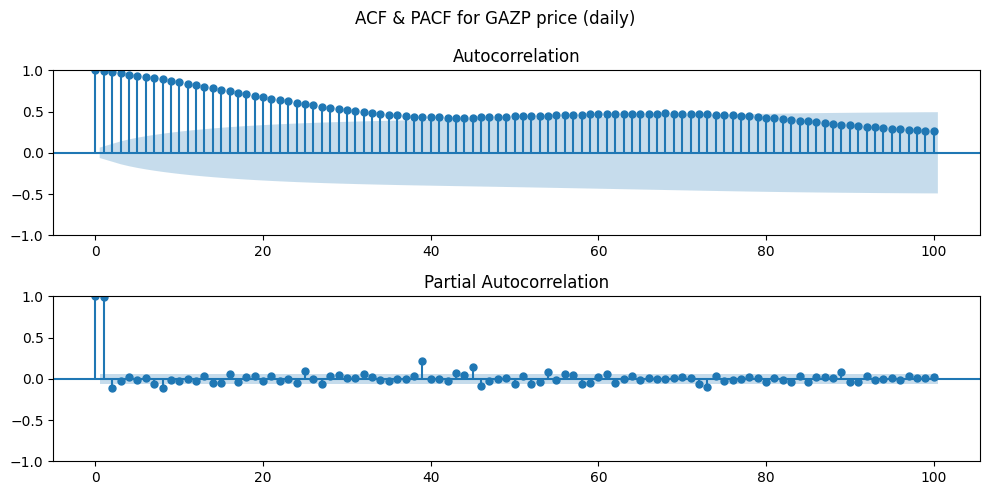

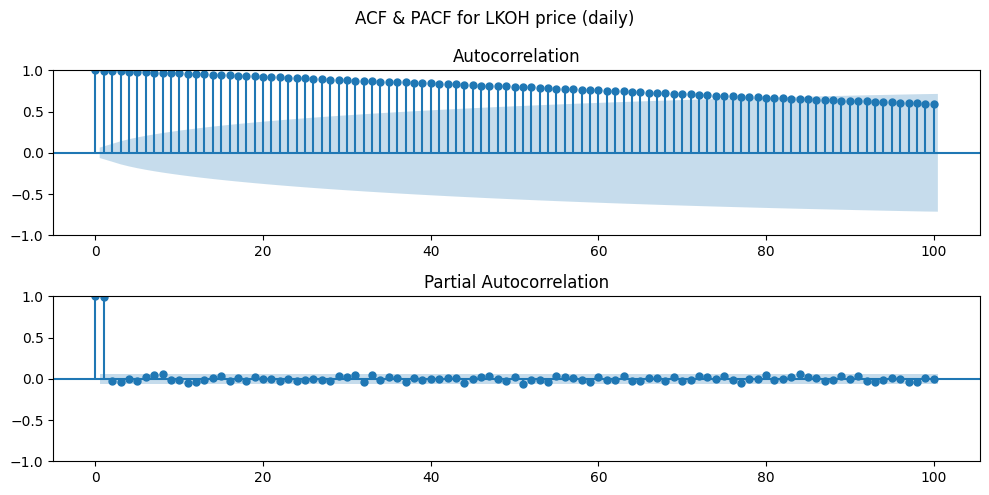

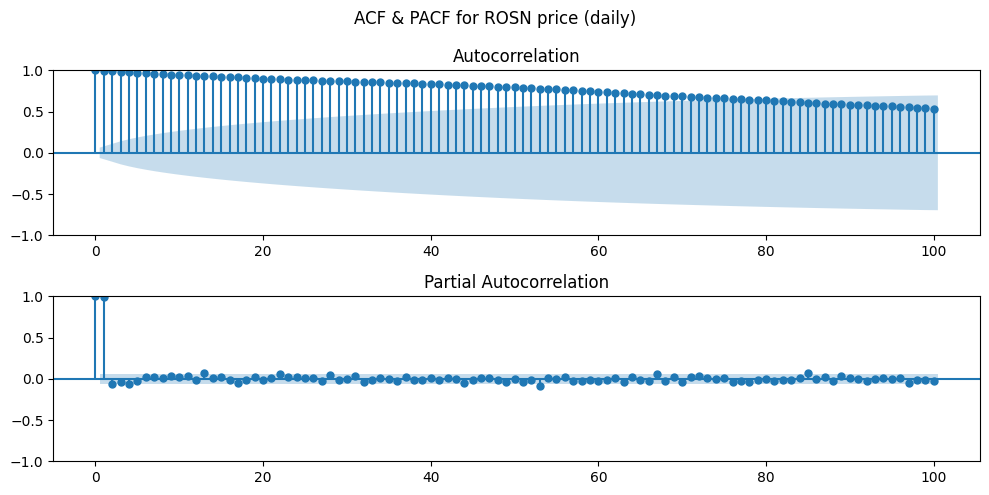

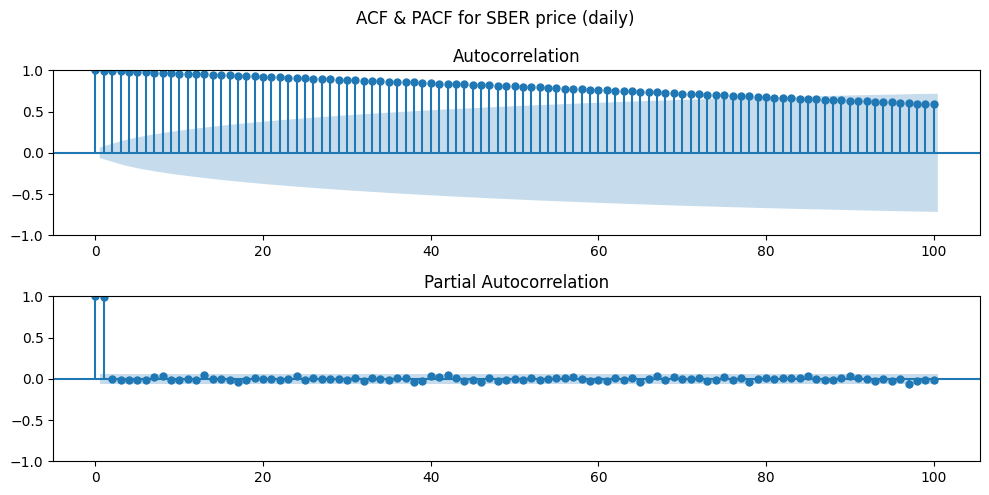

In [248]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


for ticker, df in stocks_data_daily.items():
    fig, ax = plt.subplots(2, 1, figsize=(10, 5))
    fig.suptitle(f'ACF & PACF for {ticker} price (daily)')
    plot_acf(df['close'], lags=100, ax=ax[0])
    plot_pacf(df['close'], lags=100, ax=ax[1])
    plt.tight_layout()
    plt.show()

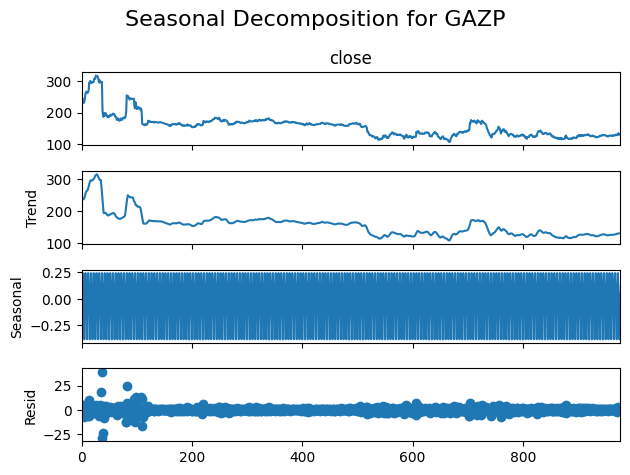

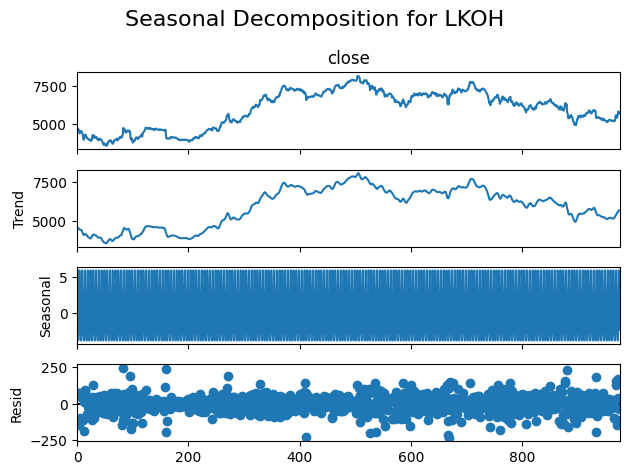

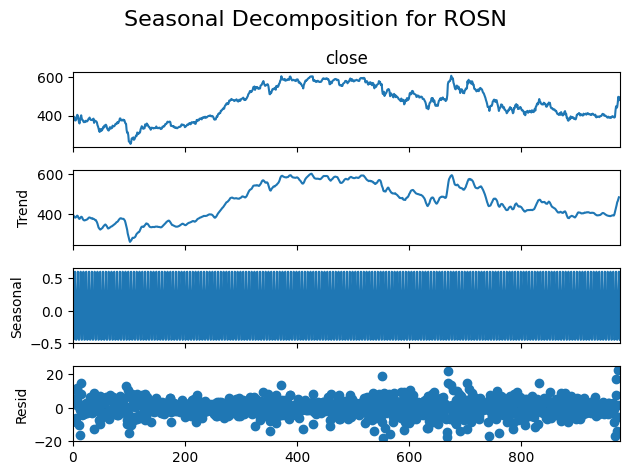

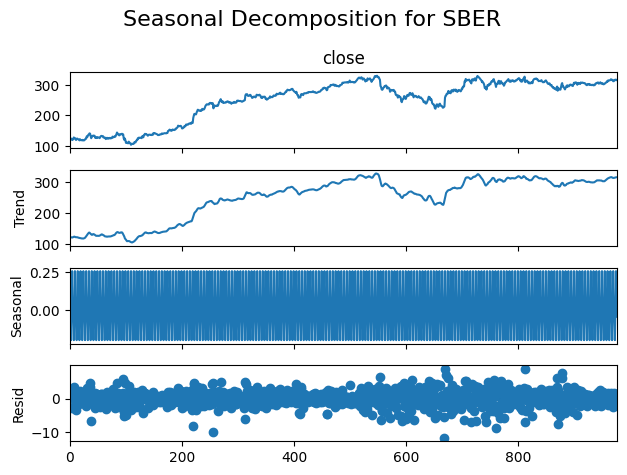

In [249]:
from statsmodels.tsa.seasonal import seasonal_decompose

for ticker, df in stocks_data_daily.items():
    res = seasonal_decompose(df['close'], period=5, model='additive')
    fig = res.plot()
    fig.suptitle(f"Seasonal Decomposition for {ticker}", fontsize=16)
    plt.tight_layout()
    plt.show()

In [250]:
stocks_data_1w_daily_df = pd.concat(stocks_data_daily.values(), keys=stocks_data_daily.keys()).reset_index(level=0).rename(columns={'level_0': 'company'})

In [251]:
fig = go.Figure()

for ticker in stocks_data_1w_daily_df['company'].unique():
    df = stocks_data_1w_daily_df[stocks_data_1w_daily_df['company'] == ticker]
    fig.add_trace(
        go.Scatter(
            x=df['begin'],
            y=df['close'],
            mode="lines",
            name=ticker
        )
    )

fig.update_layout(
    title="Stock Prices (Daily)",
    xaxis_title="Date",
    yaxis_title="Price",
    template="plotly_white"
)
fig.show()

In [252]:
# Log scale

fig = go.Figure()

for ticker in stocks_data_1w_daily_df['company'].unique():
    df = stocks_data_1w_daily_df[stocks_data_1w_daily_df['company'] == ticker]
    fig.add_trace(
        go.Scatter(
            x=df['begin'],
            y=np.log(df['close']),
            mode="lines",
            name=ticker
        )
    )

fig.update_layout(
    title="Stock Prices (Daily, Log Scale)",
    xaxis_title="Date",
    yaxis_title="Log(Price)",
    template="plotly_white"
)
fig.show()

Итоги исследования цены акций:
- Сезонность присутствует, но почти незаметная
- График ACF медленно падает. Есть тренд.
- На графике PACF все значения, кроме 1, находятся около "синей зоны".

Получается, что есть зависимость между многими предыдущими значениями, но прямых зависимостей нет.

Модели сложно будет адекватно предсказать такое. Попробуем взять что-нибудь другое в качестве target.

### 1.4. Анализ доходности

Попробуем взять не цену акций, а доходность акции, если купим сегодня, а продадим через неделю.

Возьмем log доходность:
$$
r_{t,t+5} = \log(P_{t+5}) - \log(P_t)
$$

In [ ]:
# Посчитаем log доходность для всех акций

stocks_returns_1w_daily = {}

for ticker, df in stocks_data_daily.items():
    df = df.copy()
    df['target_log_return'] = log_return(df['close'], periods=5)
    df['target_date'] = df['begin'].shift(5)
    df['target_price'] = df['close'].shift(5)
    stocks_returns_1w_daily[ticker] = df.dropna().reset_index(drop=True)

display(stocks_returns_1w_daily['GAZP'].tail(10))
stocks_returns_1w_daily['GAZP'].shape

,begin,close,target_log_return,target_date,target_price
962,2026-02-27,127.05,0.007664,2026-02-20,126.08
963,2026-03-02,129.56,0.013130,2026-02-23,127.87
964,2026-03-03,129.32,0.023867,2026-02-24,126.27
965,2026-03-04,128.01,0.008158,2026-02-25,126.97
966,2026-03-05,127.70,0.008888,2026-02-26,126.57
967,2026-03-06,131.64,0.035490,2026-02-27,127.05
968,2026-03-09,134.00,0.033696,2026-03-02,129.56
969,2026-03-10,129.63,0.002394,2026-03-03,129.32
970,2026-03-11,129.96,0.015118,2026-03-04,128.01
971,2026-03-12,129.97,0.017620,2026-03-05,127.70


(972, 5)

In [ ]:
# График log доходности, рядом с графиком цены

from plotly.subplots import make_subplots

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Scatter(x=stocks_returns_1w_daily['GAZP'].index, y=stocks_returns_1w_daily['GAZP']['close'], name="price"),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(x=stocks_returns_1w_daily['GAZP'].index, y=stocks_returns_1w_daily['GAZP']['target_log_return'], name="log return after 1 week"),
    secondary_y=True,
)


# Add figure title
fig.update_layout(
    title_text="GAZP: Price and Log Return After 1 Week"
)

fig.update_xaxes(title_text="Date")

fig.update_yaxes(title_text="price", secondary_y=False)
fig.update_yaxes(title_text="log return", secondary_y=True)

fig.show()

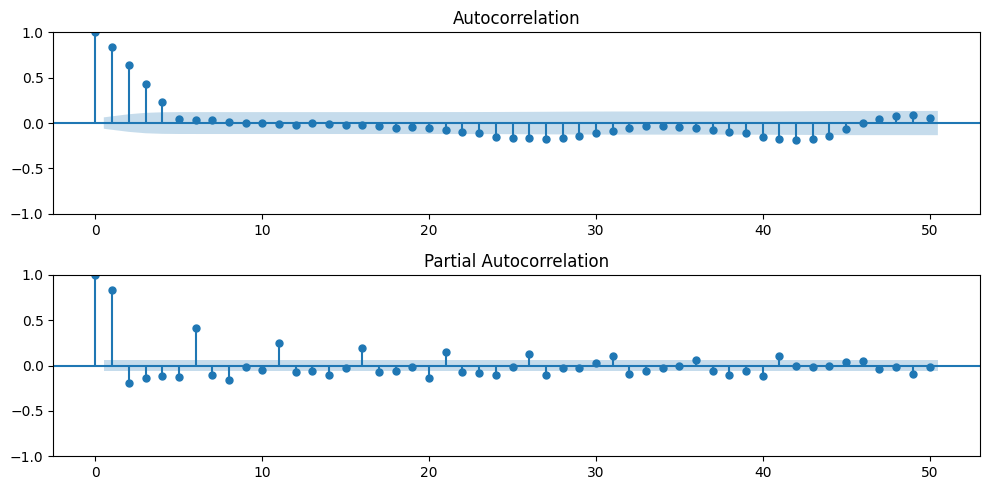

In [ ]:
# Проанализируем

fig, ax = plt.subplots(2, 1, figsize=(10, 5))
plot_acf(stocks_returns_1w_daily['GAZP']['target_log_return'], lags=50, ax=ax[0]);
plot_pacf(stocks_returns_1w_daily['GAZP']['target_log_return'], lags=50, ax=ax[1]);
plt.tight_layout()
plt.show()

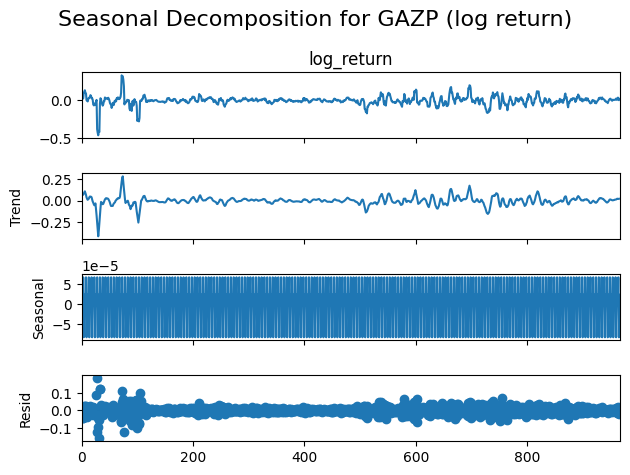

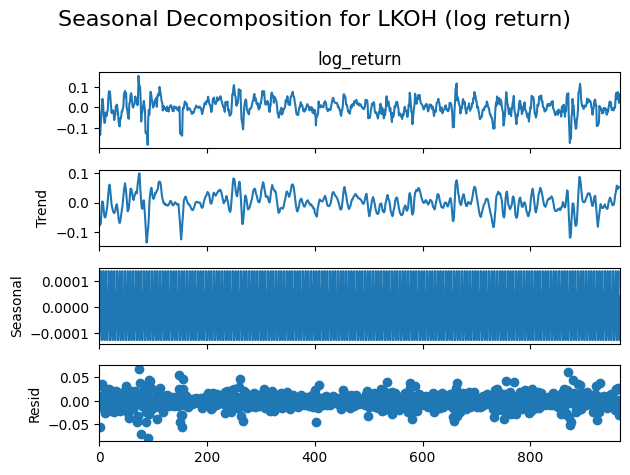

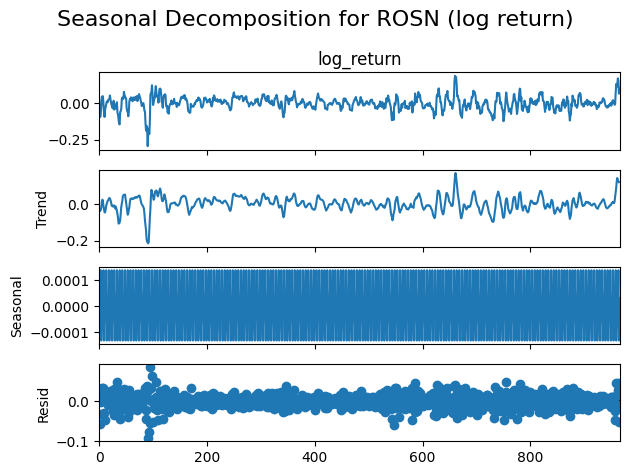

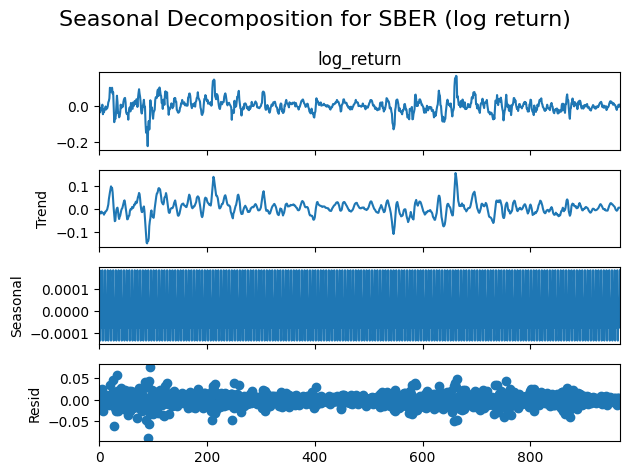

In [ ]:
for ticker, df in stocks_returns_1w_daily.items():
    res = seasonal_decompose(df['log_return'], period=5, model='additive')
    fig = res.plot()
    fig.suptitle(f"Seasonal Decomposition for {ticker} (log return)", fontsize=16)
    plt.tight_layout()
    plt.show()

Здесь мы уже видим кое что интересное.

ACF быстро затухает, за 6 дней.

А на PACF наблюдаем всплески, которые происходят примерно каждые 7 дней.

Стоит попробовать модель `AR(2)`.

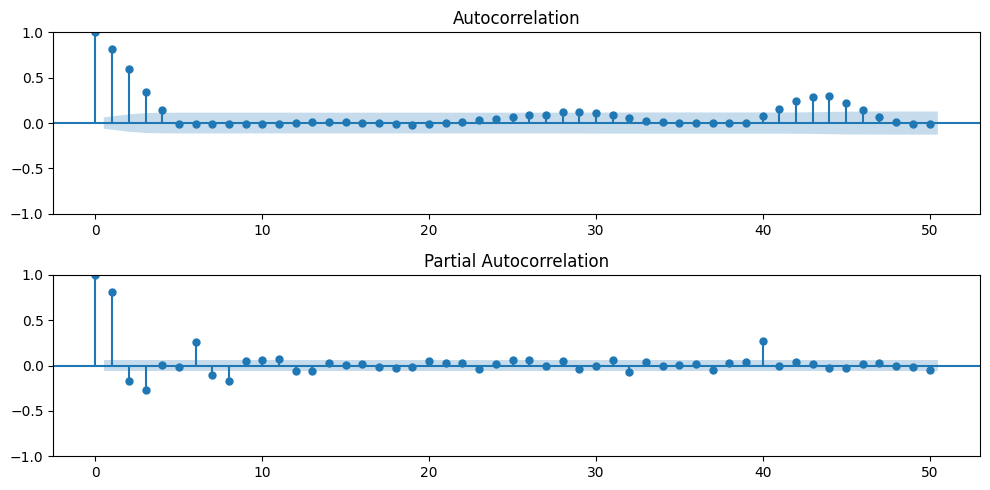

In [ ]:
# Попробуем квадраты

fig, ax = plt.subplots(2, 1, figsize=(10, 5))
plot_acf(stocks_returns_1w_daily['GAZP']['target_log_return'] ** 2, lags=50, ax=ax[0]);
plot_pacf(stocks_returns_1w_daily['GAZP']['target_log_return'] ** 2, lags=50, ax=ax[1]);
plt.tight_layout()
plt.show()

### 1.4. Пробуем SARIMA модель

In [ ]:
# Xtrain_stocks, Xtest_stocks, ytrain_stocks, ytest_stocks = {}, {}, {}, {}

# for ticker, df in stocks_returns_1w_daily.items():
#     Xtrain_stocks[ticker], Xtest_stocks[ticker], ytrain_stocks[ticker], ytest_stocks[ticker] = train_test_split_by_date(
#         df=df, 
#         date_column='begin',
#         target_column='log_return',
#         test_size=0.2
#     )

# Xtrain_stocks['GAZP'].head()

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.statespace.sarimax import SARIMAX

results = {}

tscv_sarima = TimeSeriesSplit(test_size=10, n_splits=20)
for order in ((1,0,0), (2,0,0), (1,0,1)):
    errors = np.zeros(tscv_sarima.get_n_splits(stocks_returns_1w_daily['GAZP']['close']))
    for i, (train_index, test_index) in enumerate(tscv_sarima.split(stocks_returns_1w_daily['GAZP'])):
        X = stocks_returns_1w_daily['GAZP']['close'].iloc[np.concatenate([train_index, test_index])]
        ytest_price = stocks_returns_1w_daily['GAZP']['close'].iloc[test_index]
        ytrain = stocks_returns_1w_daily['GAZP']['target_log_return'].iloc[train_index]
        ytest = stocks_returns_1w_daily['GAZP']['target_log_return'].iloc[test_index]
        print(f"Split {i+1}:")
        print(f"  Data: {ytrain.index.min()} - {ytrain.index.max()} ({len(ytrain)} samples)")
        model = SARIMAX(ytrain, order=order, seasonal_order=(0, 0, 0, 0), enforce_stationarity=False, enforce_invertibility=False)
        fitted = model.fit(disp=False)
        forecast = fitted.forecast(steps=10)
        current_price = inverse_log_return(forecast, X.shift(5)[-10:])
        mse = mean_squared_error(ytest, forecast)
        errors[i] = mse
        print(f"  MSE: {mse:.6f}")
        print(f"  Forecast: {current_price.values}")
        print(f"  Actual:   {inverse_log_return(ytest, X.shift(5)[-10:]).values}\n")
    med_error = np.median(errors)
    results[order] = med_error
    print(f"Median MSE for order {order}: {med_error:.6f}\n")
    

Split 1:
  Data: 0 - 771 (772 samples)
  MSE: 0.002266
  Forecast: [125.49102549 125.63264893 120.52881926 124.07753392 126.28293184
 128.30731111 130.37639948 129.40241094 128.77454955 128.38591914]
  Actual:   [130.8  132.5  131.17 130.25 129.62 129.6  125.8  122.82 123.3  122.88]

Split 2:
  Data: 0 - 781 (782 samples)
  MSE: 0.001161
  Forecast: [123.91986576 121.15586301 119.00305317 120.07578473 120.1774071
 121.31435437 121.01919937 125.3312155  125.35894628 125.00680087]
  Actual:   [123.6  122.93 126.99 126.75 126.17 123.42 125.23 124.67 126.63 127.11]

Split 3:
  Data: 0 - 791 (792 samples)
  MSE: 0.001669
  Forecast: [124.19036426 125.88493776 125.21634888 127.09504055 127.50120546
 127.15714402 130.31110581 129.93501206 126.91245602 128.83379857]
  Actual:   [126.83 130.03 129.7  126.72 128.67 127.31 123.62 123.89 118.72 120.6 ]

Split 4:
  Data: 0 - 801 (802 samples)
  MSE: 0.003787
  Forecast: [120.57845826 118.11398589 119.24506979 114.97538563 117.40141985
 113.45318752

/home/codevryn/stocks-advisor/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



Split 9:
  Data: 0 - 851 (852 samples)
  MSE: 0.000131
  Forecast: [119.75571097 119.05850887 119.01390489 121.05253336 120.06131425
 118.42029517 117.57644962 118.72523258 117.3065055  116.62009259]
  Actual:   [120.82 119.57 120.41 118.7  117.78 120.   116.87 118.27 116.19 116.45]

Split 10:
  Data: 0 - 861 (862 samples)
  MSE: 0.000367
  Forecast: [118.86372669 115.94218503 117.48288993 115.54183331 115.90552688
 115.53548882 118.86836712 118.63264181 113.98655037 117.12326015]
  Actual:   [115.99 119.26 118.96 114.25 117.35 116.   115.82 115.18 115.5  118.31]

Split 11:
  Data: 0 - 871 (872 samples)
  MSE: 0.002952
  Forecast: [116.79362506 116.48276166 115.73132387 115.96248819 118.70632975
 124.84893478 127.12741025 119.23348345 121.0383849  118.16209887]
  Actual:   [124.5  126.83 119.   120.84 118.   116.76 115.65 115.95 116.6  117.16]

Split 12:
  Data: 0 - 881 (882 samples)
  MSE: 0.000500
  Forecast: [116.06516782 115.07472152 115.46792471 116.19484144 116.81977695
 115.8182

/home/codevryn/stocks-advisor/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/home/codevryn/stocks-advisor/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



  MSE: 0.000377
  Forecast: [124.12359912 125.19326255 124.37745706 123.9317288  126.36430247
 124.96676621 125.4416521  123.89422273 123.46204204 122.08741982]
  Actual:   [125.12 125.57 124.   123.55 122.16 123.12 120.67 120.86 121.77 121.8 ]

Split 17:
  Data: 0 - 931 (932 samples)
  MSE: 0.000721
  Forecast: [122.81719774 120.42233236 120.65299667 121.59596059 121.65473635
 123.3870848  124.06688855 123.55432976 126.05707688 126.06915331]
  Actual:   [123.51 124.17 123.64 126.13 126.13 126.43 126.02 128.53 128.4  128.13]

Split 18:
  Data: 0 - 941 (942 samples)
  MSE: 0.000474
  Forecast: [128.10056838 127.40787458 129.71002266 129.38285938 128.94784741
 128.63108662 127.78480172 128.07249969 127.84366548 125.88351728]
  Actual:   [127.95 127.22 127.6  127.45 125.56 125.35 124.21 122.99 125.25 125.86]

Split 19:
  Data: 0 - 951 (952 samples)
  MSE: 0.000106
  Forecast: [125.59983084 124.41651152 123.16058286 125.39492092 125.98148905
 126.87208662 126.83515477 125.74043786 126.3590

/home/codevryn/stocks-advisor/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



  MSE: 0.000324
  Forecast: [126.65631962 128.35746491 126.67147601 127.30671926 126.84997806
 127.28442831 129.75941677 129.48604385 128.14711233 127.81410553]
  Actual:   [127.05 129.56 129.32 128.01 127.7  131.64 134.   129.63 129.96 129.97]

Median MSE for order (1, 0, 0): 0.000815

Split 1:
  Data: 0 - 771 (772 samples)
  MSE: 0.002146
  Forecast: [126.16048066 126.73583116 121.80988097 125.48353751 127.70720367
 129.6875833  131.67641699 130.57432749 129.81795616 129.30600345]
  Actual:   [130.8  132.5  131.17 130.25 129.62 129.6  125.8  122.82 123.3  122.88]

Split 2:
  Data: 0 - 781 (782 samples)
  MSE: 0.000790
  Forecast: [124.18067736 121.81634547 119.94074961 121.17994853 121.33660087
 122.46810269 122.10998869 126.37330301 126.30202974 125.84553754]
  Actual:   [123.6  122.93 126.99 126.75 126.17 123.42 125.23 124.67 126.63 127.11]

Split 3:
  Data: 0 - 791 (792 samples)
  MSE: 0.001618
  Forecast: [124.37541039 126.01704773 125.26247742 127.0737985  127.43545709
 127.0664

/home/codevryn/stocks-advisor/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/home/codevryn/stocks-advisor/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



  MSE: 0.000714
  Forecast: [134.82819921 131.52955986 133.13554884 132.09035126 128.36701807
 130.21875963 130.69384281 131.83716725 134.51195282 134.17634817]
  Actual:   [132.   132.   132.8  135.23 134.7  135.38 134.38 130.7  131.1  130.49]

Split 8:
  Data: 0 - 841 (842 samples)
  MSE: 0.001900
  Forecast: [131.9445775  131.79057393 128.83257168 129.72377731 129.48731193
 131.25874053 132.69359442 133.10034999 130.06520449 130.09225467]
  Actual:   [132.   133.24 133.5  130.35 130.3  125.71 124.   123.14 124.56 122.97]

Split 9:
  Data: 0 - 851 (852 samples)
  MSE: 0.000240
  Forecast: [119.68215181 119.40148732 119.72439345 122.00893816 121.12031389
 119.48844401 118.60560056 119.69971158 118.18808953 117.40874013]
  Actual:   [120.82 119.57 120.41 118.7  117.78 120.   116.87 118.27 116.19 116.45]

Split 10:
  Data: 0 - 861 (862 samples)
  MSE: 0.000374
  Forecast: [119.14735423 116.29966716 117.85809653 115.89676201 116.23578391
 115.83413972 119.14284709 118.87454829 114.189982

In [ ]:
# SARIMAX модель
from sklearn.metrics import f1_score
from statsmodels.tsa.statespace.sarimax import SARIMAX

for order in ((1,0,0), (2,0,0), (1,0,1)):
    # Ряд логарифмирован, поэтому он уже стационарный. Сезонности также нет.
    model = SARIMAX(stocks_returns_1w_daily['GAZP']['log_return'], seasonal_order=(0, 0, 0, 0), enforce_stationarity=False, enforce_invertibility=False)
    fitted = model.fit(disp=False)
    print(fitted)
    forecast = fitted.forecast(steps=10)
    print(forecast)


970    0.004676
971    0.004169
972    0.003717
973    0.003314
974    0.002955
975    0.002635
976    0.002349
977    0.002094
978    0.001867
979    0.001665
Name: predicted_mean, dtype: float64
970    0.004676
971    0.004169
972    0.003717
973    0.003314
974    0.002955
975    0.002635
976    0.002349
977    0.002094
978    0.001867
979    0.001665
Name: predicted_mean, dtype: float64
970    0.004676
971    0.004169
972    0.003717
973    0.003314
974    0.002955
975    0.002635
976    0.002349
977    0.002094
978    0.001867
979    0.001665
Name: predicted_mean, dtype: float64
